GradCAM++ Normal Test Pictures

In [1]:
import pickle
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

# Set seaborn style
sns.set_theme(style="whitegrid")
plt.rcParams['ytick.left'] = True
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = '500'  # medium weight
plt.rcParams['font.stretch'] = 'semi-expanded'  # slightly expanded
plt.rcParams['figure.dpi'] = 300

In [2]:
data_path = f'../plots/border_cam_plot_data.pkl'
with open(data_path, 'rb') as f:
    plot_data = pickle.load(f)
df_matched = plot_data['df_matched']
df_ood = plot_data['df_ood']

df_matched_ec = df_matched[df_matched['CAM Type'] == 'ec']
df_matched_ec['Data'] = 'ID'
df_matched_ic_bc = df_matched[df_matched['CAM Type'] != 'ec']
df_matched_ic_bc['Data'] = 'ID'
df_ood_ec = df_ood[df_ood['CAM Type'] == 'ec']
df_ood_ec['Data'] = 'OOD'
df_ood_ic_bc = df_ood[df_ood['CAM Type'] != 'ec']
df_ood_ic_bc['Data'] = 'OOD'
df_ec = pd.concat([df_matched_ec, df_ood_ec])
df_ic_bc = pd.concat([df_matched_ic_bc, df_ood_ic_bc])

df_ic = df_ic_bc[df_ic_bc['CAM Type'] == 'ic']
df_bc = df_ic_bc[df_ic_bc['CAM Type'] == 'bc']

cam_type_mapping = {'ic': 'Object', 'bc': 'Edge', 'ec': 'Background'}
view_mapping = {'f': 'Full', 'r': 'Restricted', 'er': 'Extra R.', 'fx': 'Fixed'}
df_ec['CAM Type'] = df_ec['CAM Type'].map(cam_type_mapping)
df_ec['View'] = df_ec['View'].map(view_mapping)
df_ic_bc['CAM Type'] = df_ic_bc['CAM Type'].map(cam_type_mapping)
df_ic_bc['View'] = df_ic_bc['View'].map(view_mapping)
df_ic['CAM Type'] = df_ic['CAM Type'].map(cam_type_mapping)
df_ic['View'] = df_ic['View'].map(view_mapping)
df_bc['CAM Type'] = df_bc['CAM Type'].map(cam_type_mapping)
df_bc['View'] = df_bc['View'].map(view_mapping)

/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1695401640.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_ec['Data'] = 'ID'
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1695401640.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_ic_bc['Data'] = 'ID'
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1695401640.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

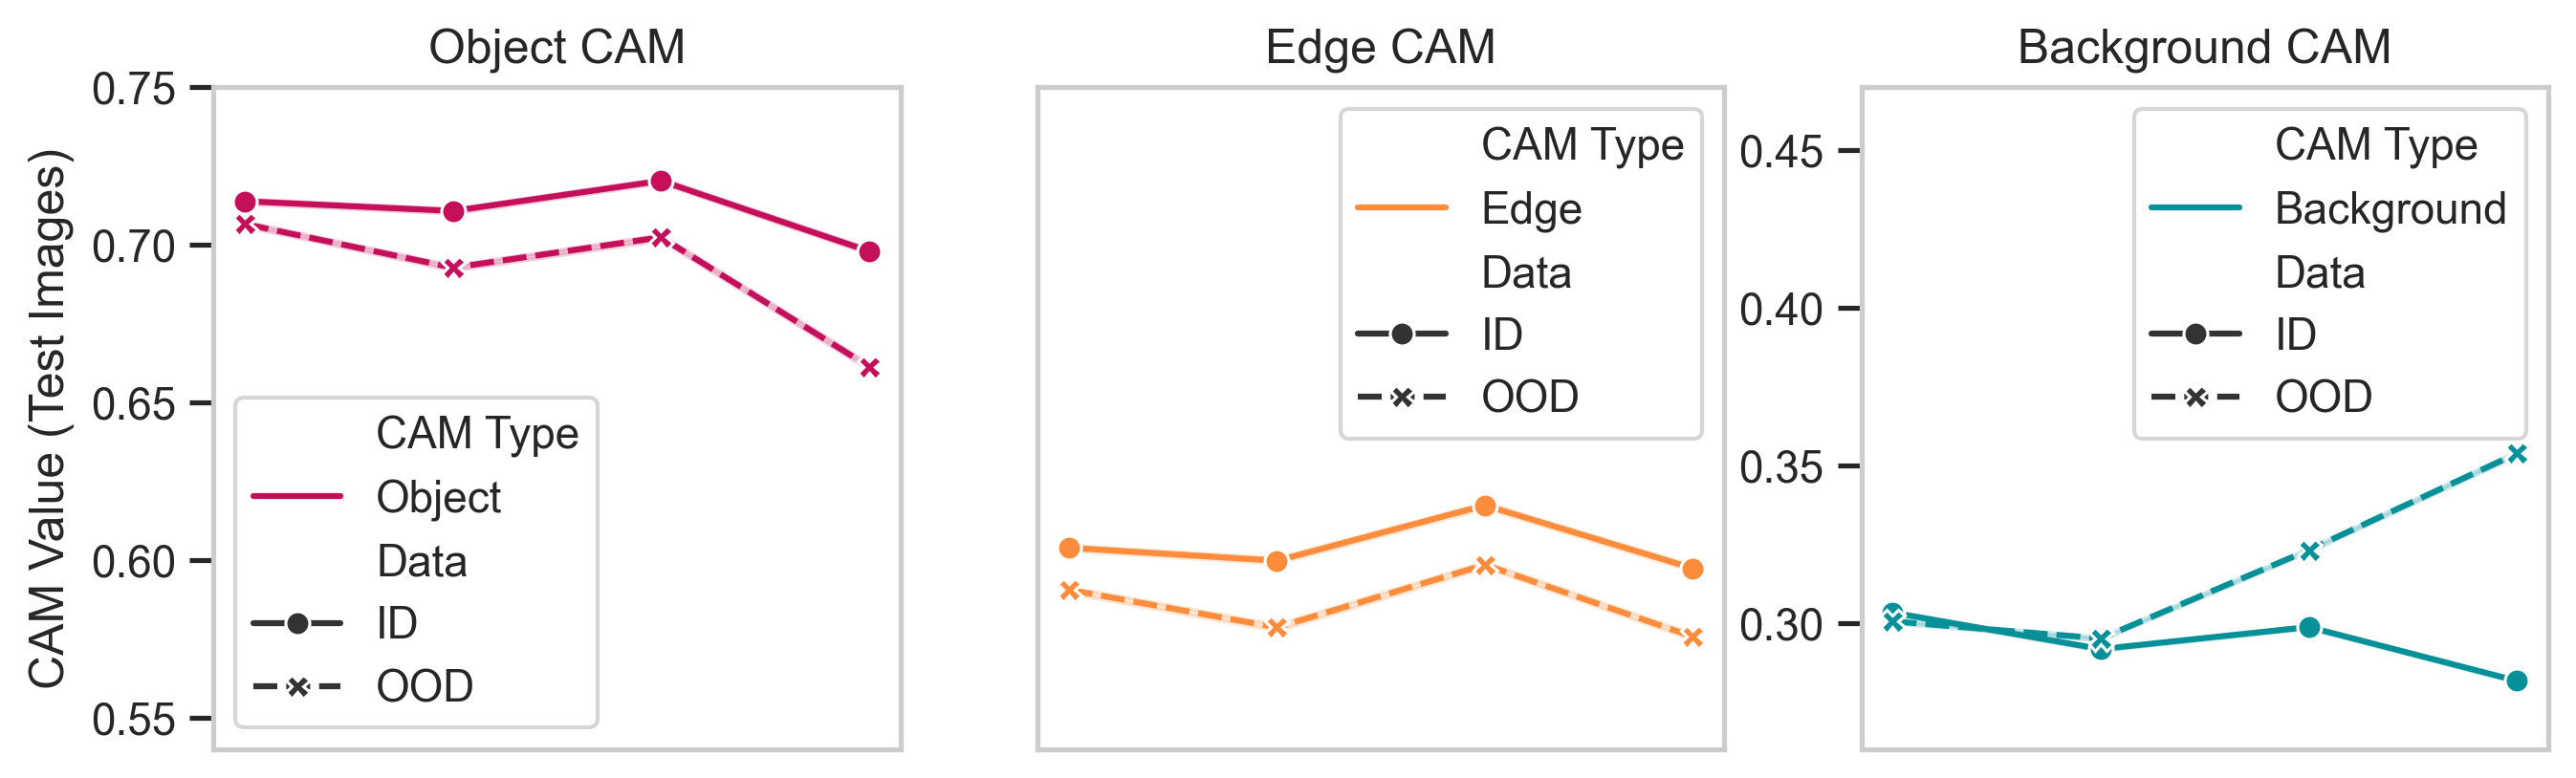

In [7]:
palette = {
    'Object': '#C40F5B',
    'Edge': '#FD8D3C',
    'Background': '#089099',
}

# Create figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(10.5, 3))

sns.lineplot(
    ax=ax1,
    data=df_ic,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,
)

sns.lineplot(
    ax=ax2,
    data=df_bc,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,
)

lines = sns.lineplot(
    ax=ax3,
    data=df_ec,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True
)

# Rest of the styling remains the same
ax1.grid(False)
ax2.grid(False)
ax3.grid(False)
ax2.set_ylabel('')
ax3.set_ylabel('')
ax2.set_yticks([])

ax1.set_ylim([0.54, 0.75])
ax2.set_ylim([0.54, 0.75])
ax3.set_ylim([0.26, 0.47])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_ylabel('CAM Value (Test Images)')
ax1.set_title('Object CAM')
ax2.set_title('Edge CAM')
ax3.set_title('Background CAM')
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')
ax1.set_xticks([])
ax2.set_xticks([])
ax3.set_xticks([])

plt.savefig('border_cam_plot_normal.png', bbox_inches='tight')

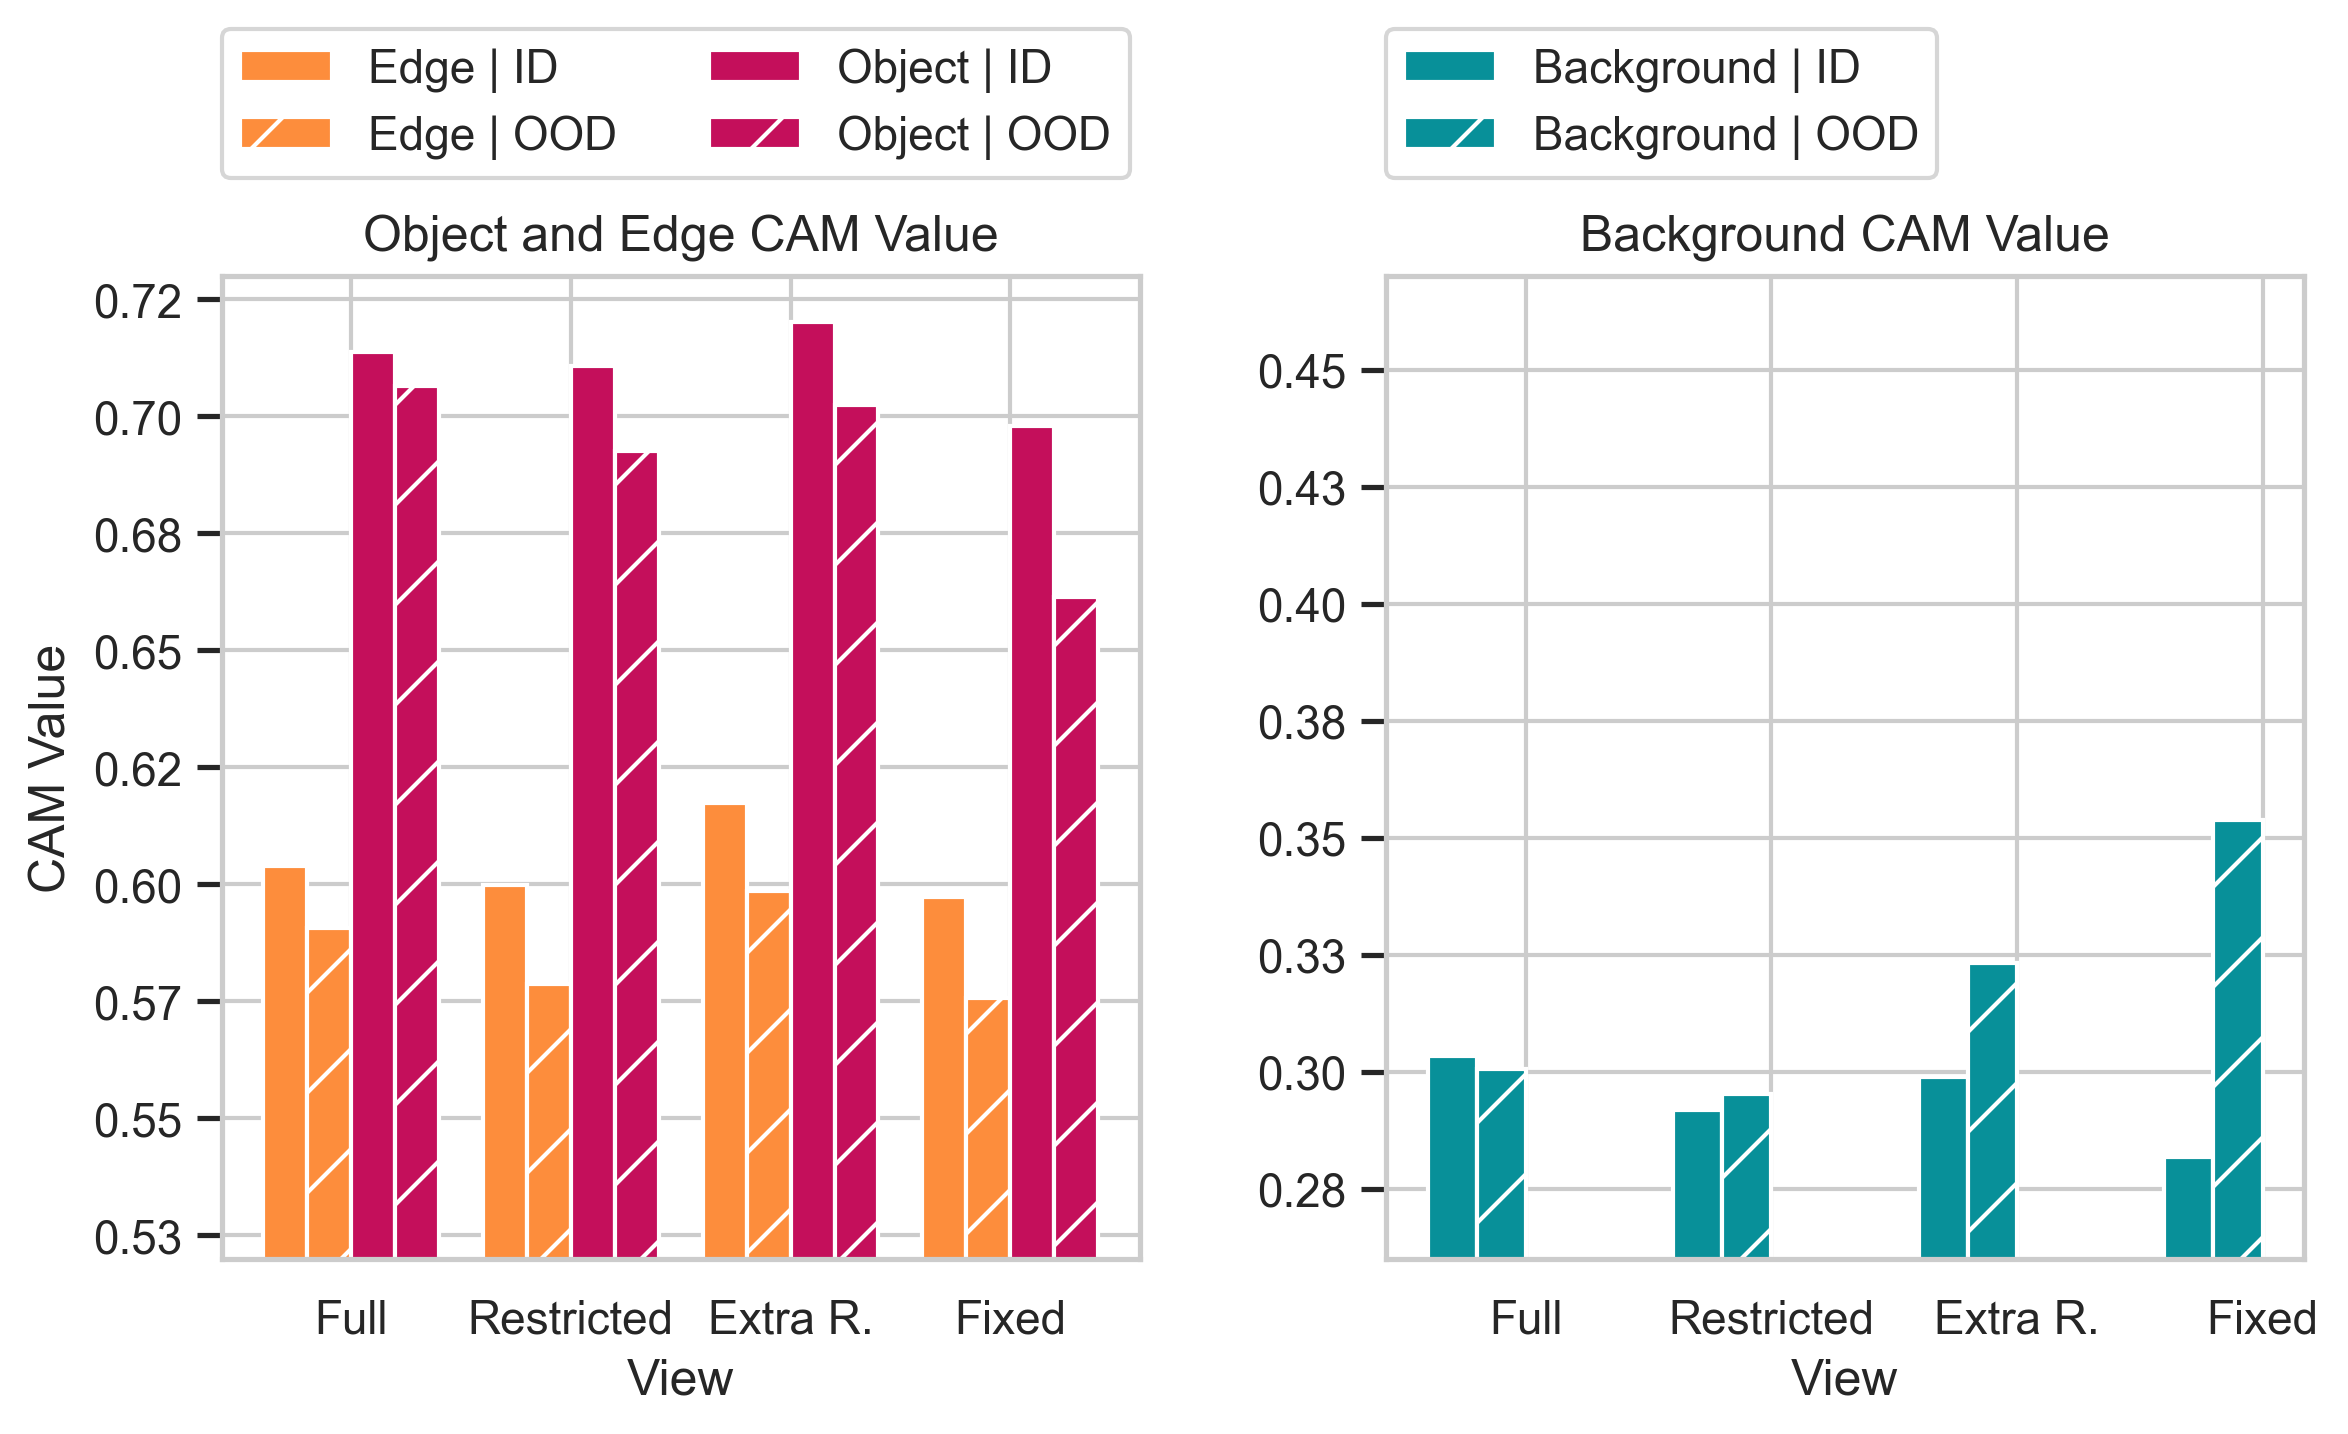

In [5]:
# Generate unique colors for CAM Types and hatches for Data
cam_types = df_ic_bc['CAM Type'].unique()
data_types = df_ic_bc['Data'].unique()
df_avg = df_ic_bc.groupby(['View', 'CAM Type', 'Data'], as_index=False).mean()
df_avg_ec = df_ec.groupby(['View', 'CAM Type', 'Data'], as_index=False).mean()

color_map = palette
hatch_map = {data: hatch for data, hatch in zip(data_types, ['', '/'])}

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))
fig.subplots_adjust(wspace=0.2)

x = np.arange(len(df_avg['View'].unique()))  # Positions for the View categories
bar_width = 0.2  # Width of each bar group
offset = 0  # Initialize offset for grouped bars

views = ['Full', 'Restricted', 'Extra R.', 'Fixed']

# Group bars by 'View'
for i, view in enumerate(views):
    view_data = df_avg[df_avg['View'] == view]
    bars = []
    offset = -1.5 * bar_width
    for j, (_, row) in enumerate(view_data.iterrows()):
        # Get the color and hatch for this bar
        color = color_map[row['CAM Type']]
        hatch = hatch_map[row['Data']]
        # Plot the bar
        bar = ax1.bar(
            x[i] + offset,  # Position of the bar
            row['Value'],  # Height (Value)
            bar_width,  # Width
            color=color,  # Color based on CAM Type
            label=f"{row['CAM Type']} | {row['Data']}" if i == 0 else "",  # Add legend only once
            hatch=hatch  # Hatch pattern based on Data
        )
        bars.append(bar)
        offset += bar_width  # Increment offset for next set of bars

for i, view in enumerate(views):
    view_data = df_avg_ec[df_avg_ec['View'] == view]
    bars = []
    offset = -1.5 * bar_width
    for j, (_, row) in enumerate(view_data.iterrows()):
        # Get the color and hatch for this bar
        color = color_map[row['CAM Type']]
        hatch = hatch_map[row['Data']]
        # Plot the bar
        bar = ax2.bar(
            x[i] + offset,  # Position of the bar
            row['Value'],  # Height (Value)
            bar_width,  # Width
            color=color,  # Color based on CAM Type
            label=f"{row['CAM Type']} | {row['Data']}" if i == 0 else "",  # Add legend only once
            hatch=hatch  # Hatch pattern based on Data
        )
        bars.append(bar)
        offset += bar_width  # Increment offset for next set of bars

# Customize the plot
ax1.set_xlabel('View')
ax1.set_ylabel('CAM Value')
ax1.set_title('Object and Edge CAM Value')
ax1.set_xticks(x)
ax1.set_xticklabels(views)
ax1.set_ylim([0.52, 0.73])


ax2.set_xlabel('View')
ax2.set_ylabel('')
ax2.set_title('Background CAM Value')
ax2.set_xticks(x)
ax2.set_xticklabels(views)
ax2.set_ylim([0.26, 0.47])

ax1.legend(ncols=2, loc=(0,1.1))
ax2.legend(loc=(0,1.1))

ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig('border_cam_normal_bar.png')

 GradCAM++ Cue-conflict (Shape)

In [8]:
data_path = f'../plots/border_cam_cue_conflict_shape_plot_data.pkl'
with open(data_path, 'rb') as f:
    plot_data = pickle.load(f)
df_matched = plot_data['df_matched']
df_ood = plot_data['df_ood']

df_matched_ec = df_matched[df_matched['CAM Type'] == 'ec']
df_matched_ec['Data'] = 'ID'
df_matched_ic_bc = df_matched[df_matched['CAM Type'] != 'ec']
df_matched_ic_bc['Data'] = 'ID'
df_ood_ec = df_ood[df_ood['CAM Type'] == 'ec']
df_ood_ec['Data'] = 'OOD'
df_ood_ic_bc = df_ood[df_ood['CAM Type'] != 'ec']
df_ood_ic_bc['Data'] = 'OOD'
df_ec = pd.concat([df_matched_ec, df_ood_ec])
df_ic_bc = pd.concat([df_matched_ic_bc, df_ood_ic_bc])

df_ic = df_ic_bc[df_ic_bc['CAM Type'] == 'ic']
df_bc = df_ic_bc[df_ic_bc['CAM Type'] == 'bc']

cam_type_mapping = {'ic': 'Object', 'bc': 'Edge', 'ec': 'Background'}
view_mapping = {'f': 'Full', 'r': 'Restricted', 'er': 'Extra R.', 'fx': 'Fixed'}
df_ec['CAM Type'] = df_ec['CAM Type'].map(cam_type_mapping)
df_ec['View'] = df_ec['View'].map(view_mapping)
df_ic_bc['CAM Type'] = df_ic_bc['CAM Type'].map(cam_type_mapping)
df_ic_bc['View'] = df_ic_bc['View'].map(view_mapping)
df_ic['CAM Type'] = df_ic['CAM Type'].map(cam_type_mapping)
df_ic['View'] = df_ic['View'].map(view_mapping)
df_bc['CAM Type'] = df_bc['CAM Type'].map(cam_type_mapping)
df_bc['View'] = df_bc['View'].map(view_mapping)

/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1836278344.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_ec['Data'] = 'ID'
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1836278344.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_ic_bc['Data'] = 'ID'
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1836278344.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

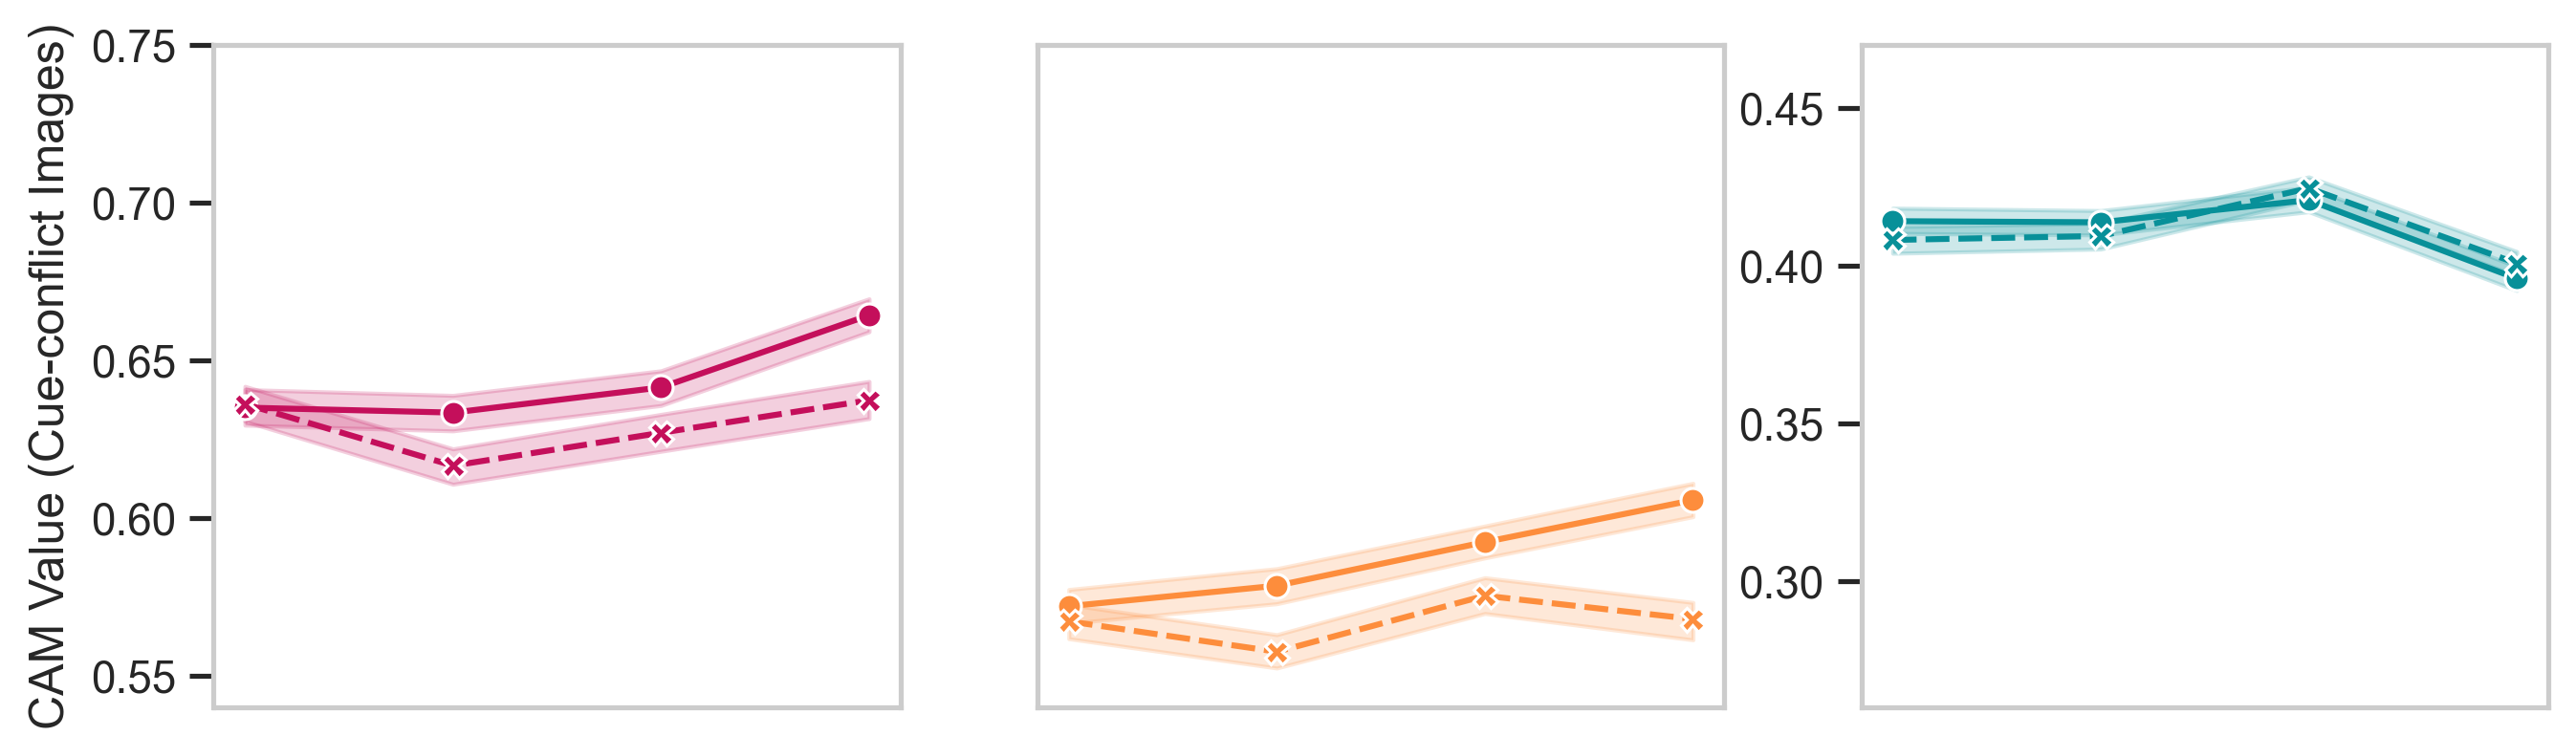

In [9]:
palette = {
    'Object': '#C40F5B',
    'Edge': '#FD8D3C',
    'Background': '#089099',
}

# Create figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(10.5, 3))

sns.lineplot(
    ax=ax1,
    data=df_ic,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,legend=False
)

sns.lineplot(
    ax=ax2,
    data=df_bc,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,legend=False
)

lines = sns.lineplot(
    ax=ax3,
    data=df_ec,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,legend=False
)

# Rest of the styling remains the same
ax1.grid(False)
ax2.grid(False)
ax3.grid(False)
ax2.set_ylabel('')
ax3.set_ylabel('')
ax2.set_yticks([])

ax1.set_ylim([0.54, 0.75])
ax2.set_ylim([0.54, 0.75])
ax3.set_ylim([0.26, 0.47])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_ylabel('CAM Value (Cue-conflict Images)')
# ax1.set_title('Object CAM')
# ax2.set_title('Edge CAM')
# ax3.set_title('Background CAM')
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')
ax1.set_xticks([])
ax2.set_xticks([])
ax3.set_xticks([])

plt.savefig('border_cam_plot_cue_conflict_shape.png', bbox_inches='tight')

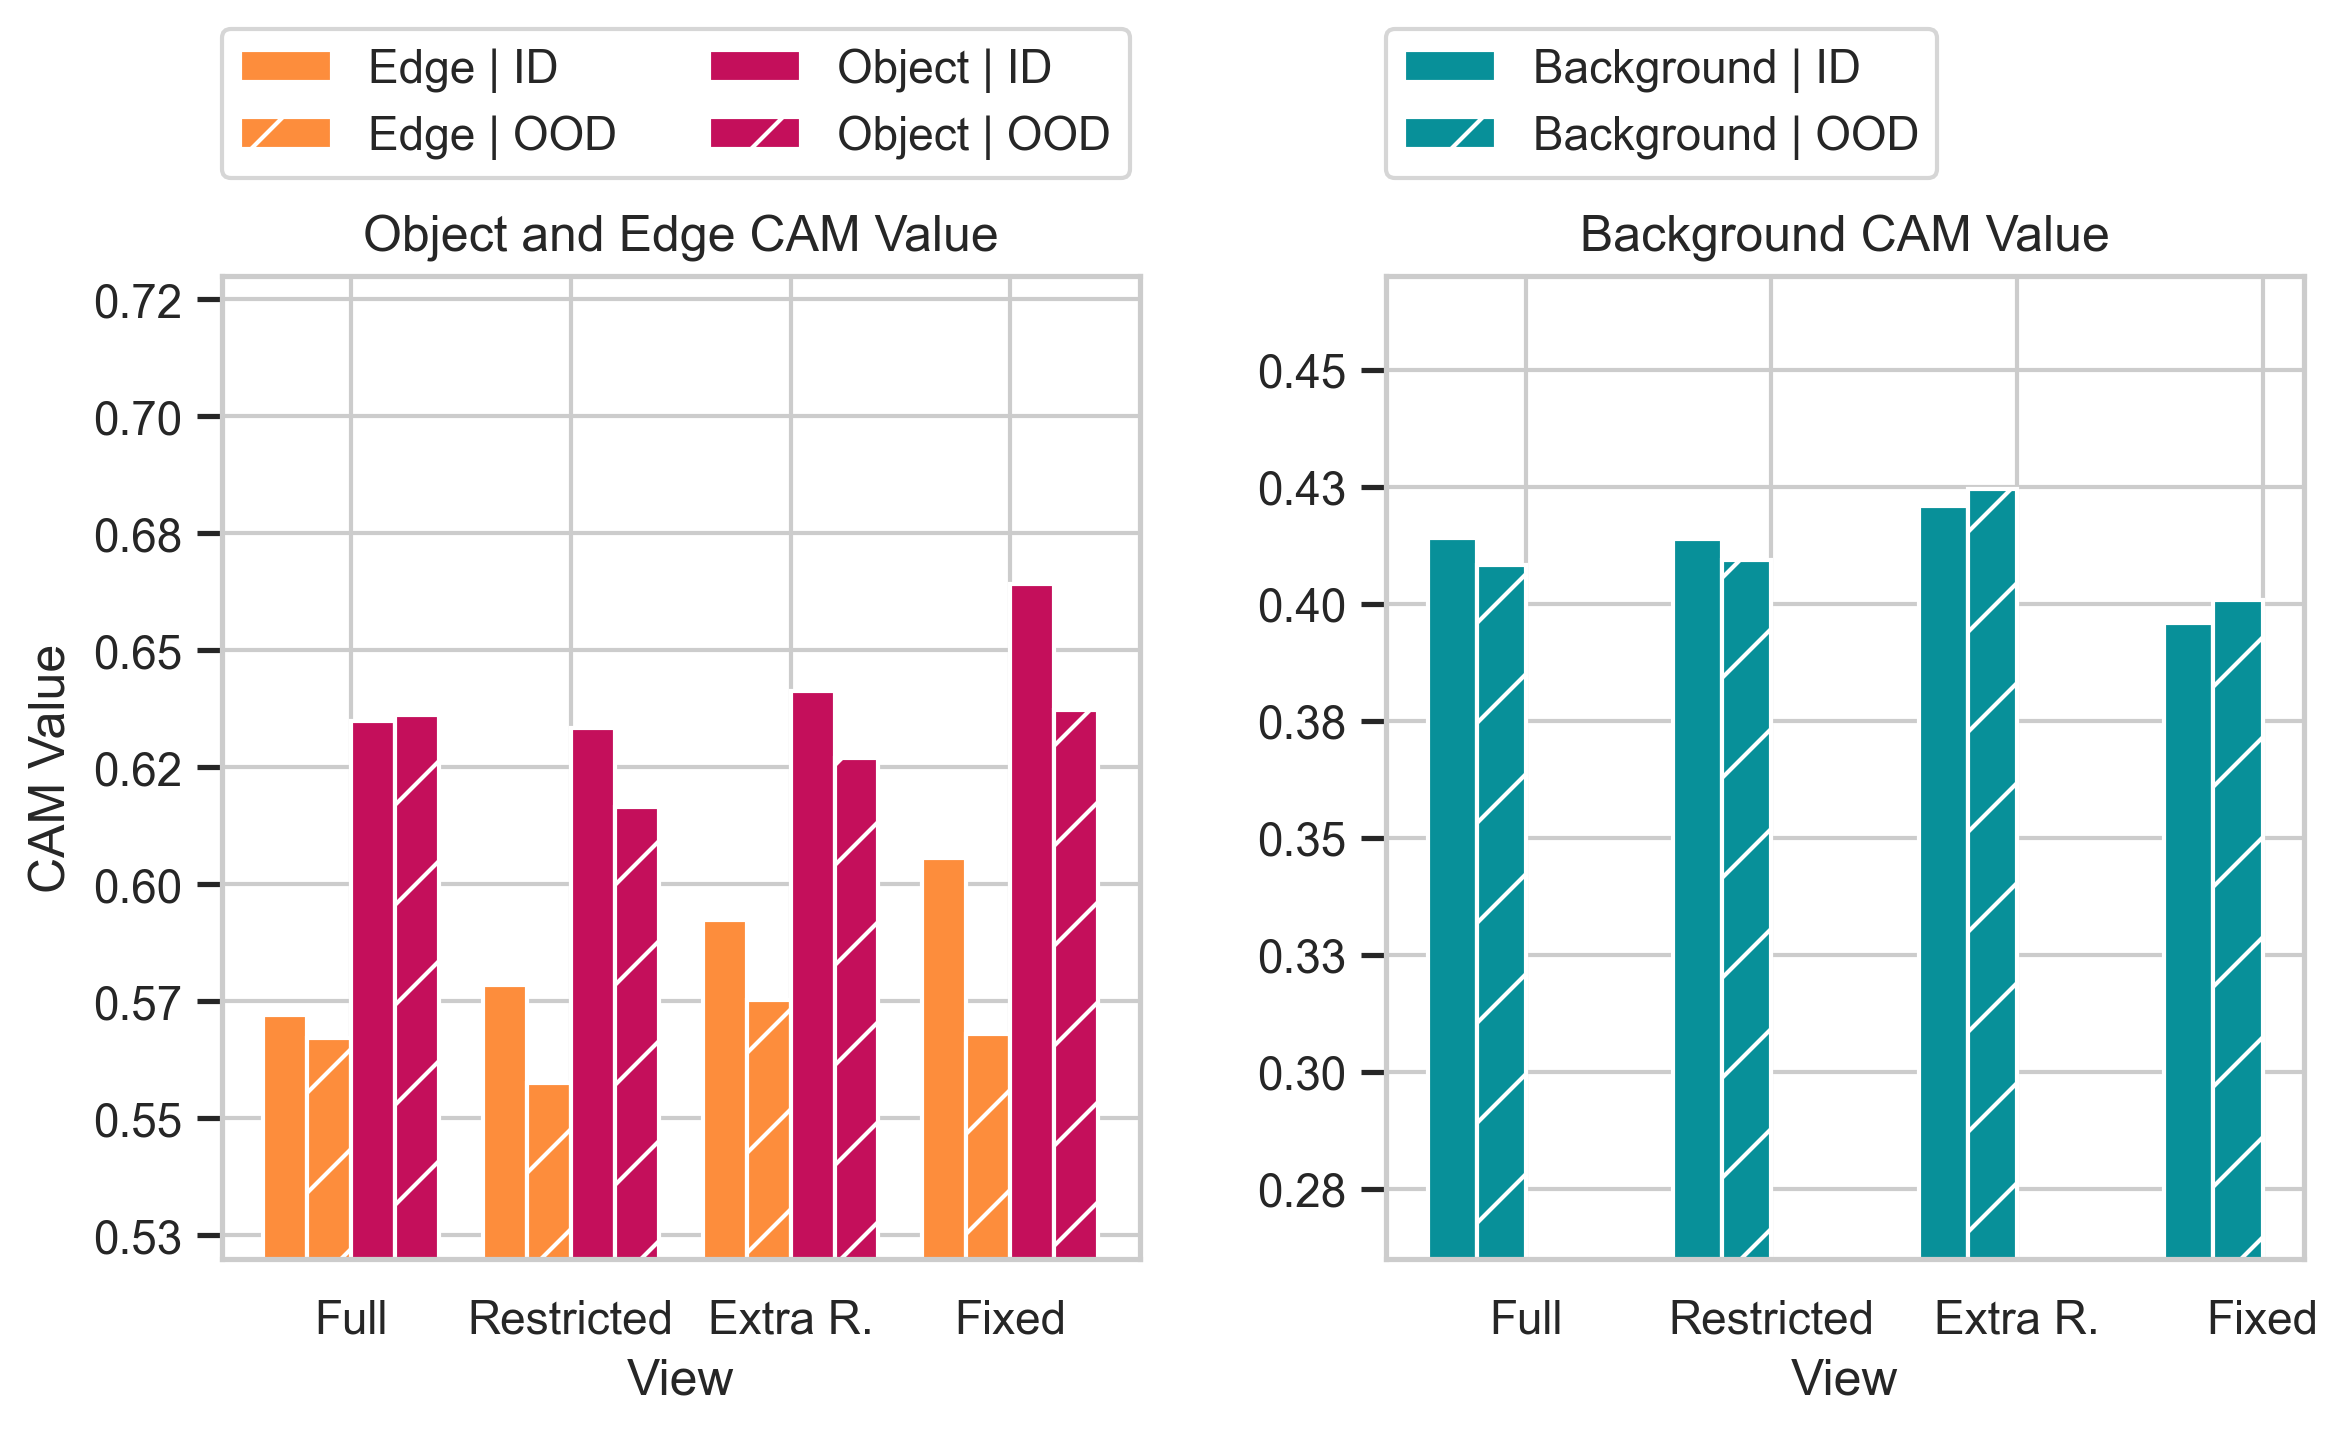

In [64]:
# Generate unique colors for CAM Types and hatches for Data
cam_types = df_ic_bc['CAM Type'].unique()
data_types = df_ic_bc['Data'].unique()
df_avg = df_ic_bc.groupby(['View', 'CAM Type', 'Data'], as_index=False).mean()
df_avg_ec = df_ec.groupby(['View', 'CAM Type', 'Data'], as_index=False).mean()

color_map = palette
hatch_map = {data: hatch for data, hatch in zip(data_types, ['', '/'])}

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))
fig.subplots_adjust(wspace=0.2)

x = np.arange(len(df_avg['View'].unique()))  # Positions for the View categories
bar_width = 0.2  # Width of each bar group
offset = 0  # Initialize offset for grouped bars

views = ['Full', 'Restricted', 'Extra R.', 'Fixed']

# Group bars by 'View'
for i, view in enumerate(views):
    view_data = df_avg[df_avg['View'] == view]
    bars = []
    offset = -1.5 * bar_width
    for j, (_, row) in enumerate(view_data.iterrows()):
        # Get the color and hatch for this bar
        color = color_map[row['CAM Type']]
        hatch = hatch_map[row['Data']]
        # Plot the bar
        bar = ax1.bar(
            x[i] + offset,  # Position of the bar
            row['Value'],  # Height (Value)
            bar_width,  # Width
            color=color,  # Color based on CAM Type
            label=f"{row['CAM Type']} | {row['Data']}" if i == 0 else "",  # Add legend only once
            hatch=hatch  # Hatch pattern based on Data
        )
        bars.append(bar)
        offset += bar_width  # Increment offset for next set of bars

for i, view in enumerate(views):
    view_data = df_avg_ec[df_avg_ec['View'] == view]
    bars = []
    offset = -1.5 * bar_width
    for j, (_, row) in enumerate(view_data.iterrows()):
        # Get the color and hatch for this bar
        color = color_map[row['CAM Type']]
        hatch = hatch_map[row['Data']]
        # Plot the bar
        bar = ax2.bar(
            x[i] + offset,  # Position of the bar
            row['Value'],  # Height (Value)
            bar_width,  # Width
            color=color,  # Color based on CAM Type
            label=f"{row['CAM Type']} | {row['Data']}" if i == 0 else "",  # Add legend only once
            hatch=hatch  # Hatch pattern based on Data
        )
        bars.append(bar)
        offset += bar_width  # Increment offset for next set of bars

# Customize the plot
ax1.set_xlabel('View')
ax1.set_ylabel('CAM Value')
ax1.set_title('Object and Edge CAM Value')
ax1.set_xticks(x)
ax1.set_xticklabels(views)
ax1.set_ylim([0.52, 0.73])

ax2.set_xlabel('View')
ax2.set_ylabel('')
ax2.set_title('Background CAM Value')
ax2.set_xticks(x)
ax2.set_xticklabels(views)
ax2.set_ylim([0.26, 0.47])

ax1.legend(ncols=2, loc=(0,1.1))
ax2.legend(loc=(0,1.1))

ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig('border_cam_plot_cue_conflict_shape_bar.png')

GradCAM++ Cue-conflict Texture

In [10]:
data_path = f'../plots/border_cam_cue_conflict_texture_plot_data.pkl'
with open(data_path, 'rb') as f:
    plot_data = pickle.load(f)
df_matched = plot_data['df_matched']
df_ood = plot_data['df_ood']

df_matched_ec = df_matched[df_matched['CAM Type'] == 'ec']
df_matched_ec['Data'] = 'ID'
df_matched_ic_bc = df_matched[df_matched['CAM Type'] != 'ec']
df_matched_ic_bc['Data'] = 'ID'
df_ood_ec = df_ood[df_ood['CAM Type'] == 'ec']
df_ood_ec['Data'] = 'OOD'
df_ood_ic_bc = df_ood[df_ood['CAM Type'] != 'ec']
df_ood_ic_bc['Data'] = 'OOD'
df_ec = pd.concat([df_matched_ec, df_ood_ec])
df_ic_bc = pd.concat([df_matched_ic_bc, df_ood_ic_bc])

df_ic = df_ic_bc[df_ic_bc['CAM Type'] == 'ic']
df_bc = df_ic_bc[df_ic_bc['CAM Type'] == 'bc']

cam_type_mapping = {'ic': 'Object', 'bc': 'Edge', 'ec': 'Background'}
view_mapping = {'f': 'Full', 'r': 'Restricted', 'er': 'Extra R.', 'fx': 'Fixed'}
df_ec['CAM Type'] = df_ec['CAM Type'].map(cam_type_mapping)
df_ec['View'] = df_ec['View'].map(view_mapping)
df_ic_bc['CAM Type'] = df_ic_bc['CAM Type'].map(cam_type_mapping)
df_ic_bc['View'] = df_ic_bc['View'].map(view_mapping)
df_ic['CAM Type'] = df_ic['CAM Type'].map(cam_type_mapping)
df_ic['View'] = df_ic['View'].map(view_mapping)
df_bc['CAM Type'] = df_bc['CAM Type'].map(cam_type_mapping)
df_bc['View'] = df_bc['View'].map(view_mapping)

/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1288547081.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_ec['Data'] = 'ID'
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1288547081.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_ic_bc['Data'] = 'ID'
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1288547081.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

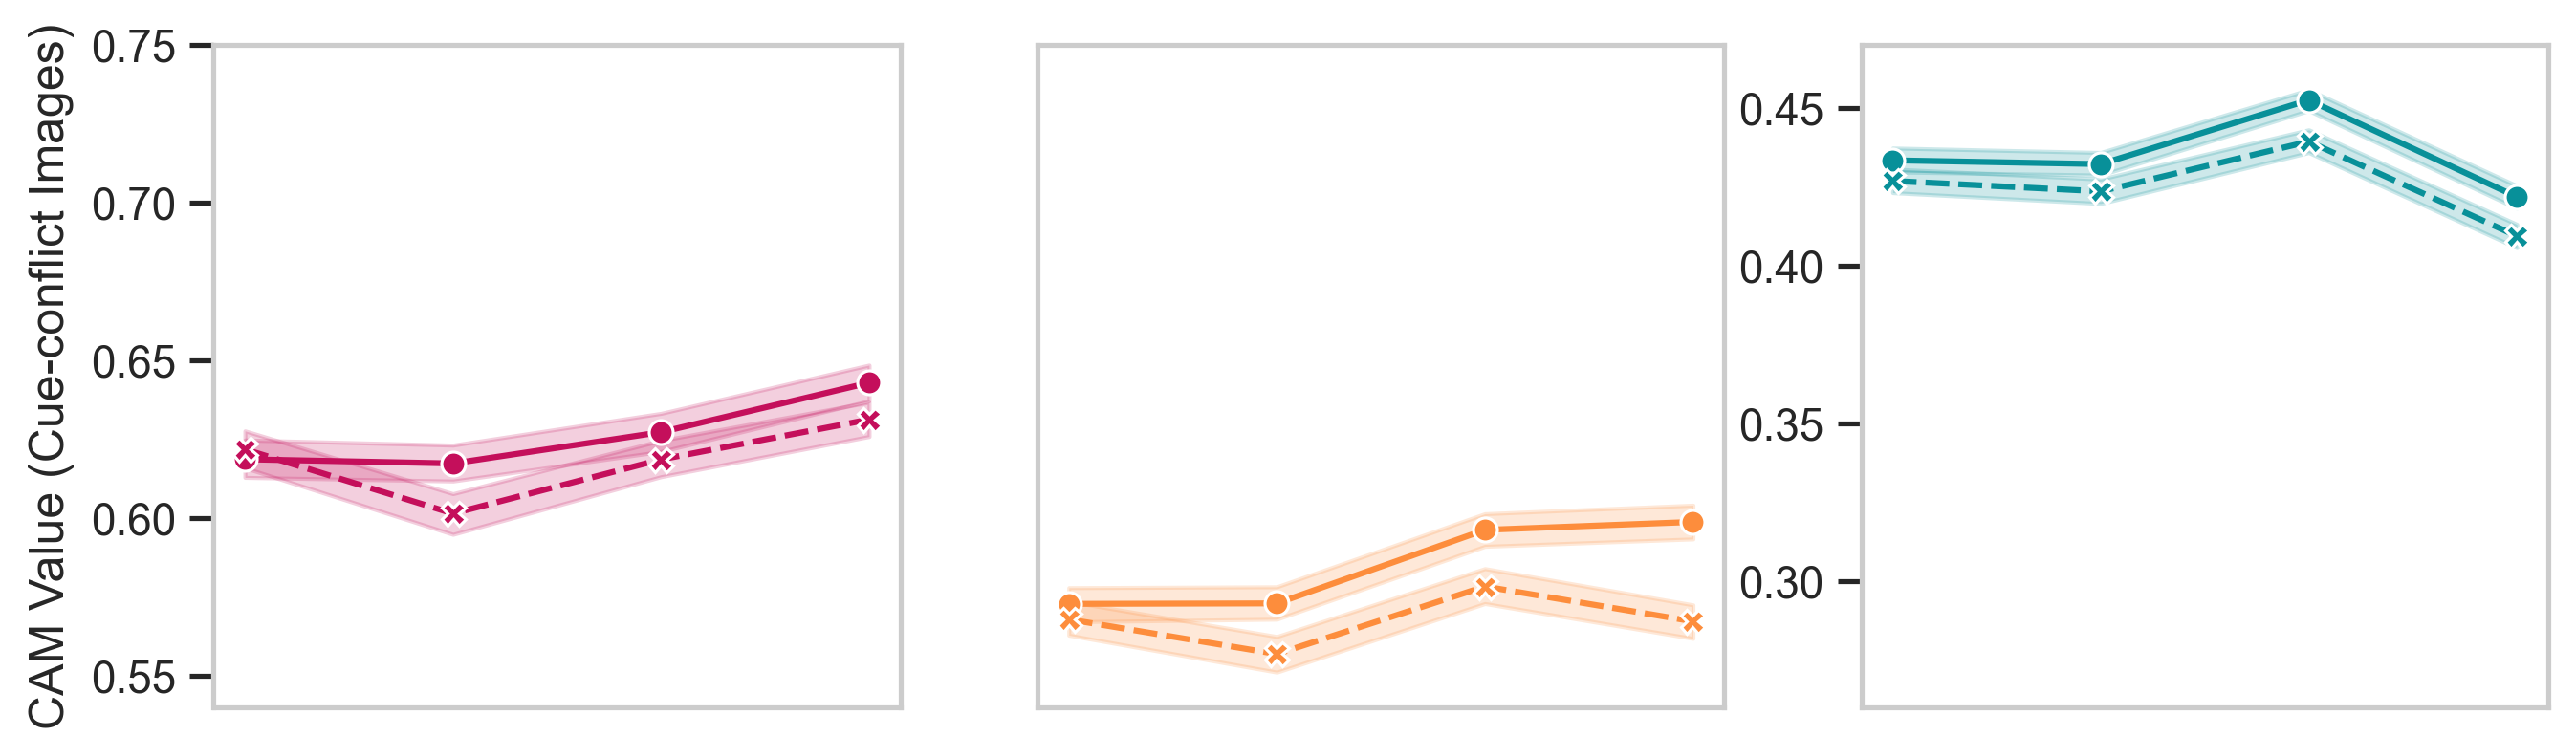

In [11]:
palette = {
    'Object': '#C40F5B',
    'Edge': '#FD8D3C',
    'Background': '#089099',
}

# Create figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(10.5, 3))

sns.lineplot(
    ax=ax1,
    data=df_ic,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,legend=False
)

sns.lineplot(
    ax=ax2,
    data=df_bc,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,legend=False
)

lines = sns.lineplot(
    ax=ax3,
    data=df_ec,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,legend=False
)

# Rest of the styling remains the same
ax1.grid(False)
ax2.grid(False)
ax3.grid(False)
ax2.set_ylabel('')
ax3.set_ylabel('')
ax2.set_yticks([])

ax1.set_ylim([0.54, 0.75])
ax2.set_ylim([0.54, 0.75])
ax3.set_ylim([0.26, 0.47])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_ylabel('CAM Value (Cue-conflict Images)')
# ax1.set_title('Object CAM')
# ax2.set_title('Edge CAM')
# ax3.set_title('Background CAM')
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')
ax1.set_xticks([])
ax2.set_xticks([])
ax3.set_xticks([])

plt.savefig('border_cam_plot_cue_conflict_texture.png', bbox_inches='tight')

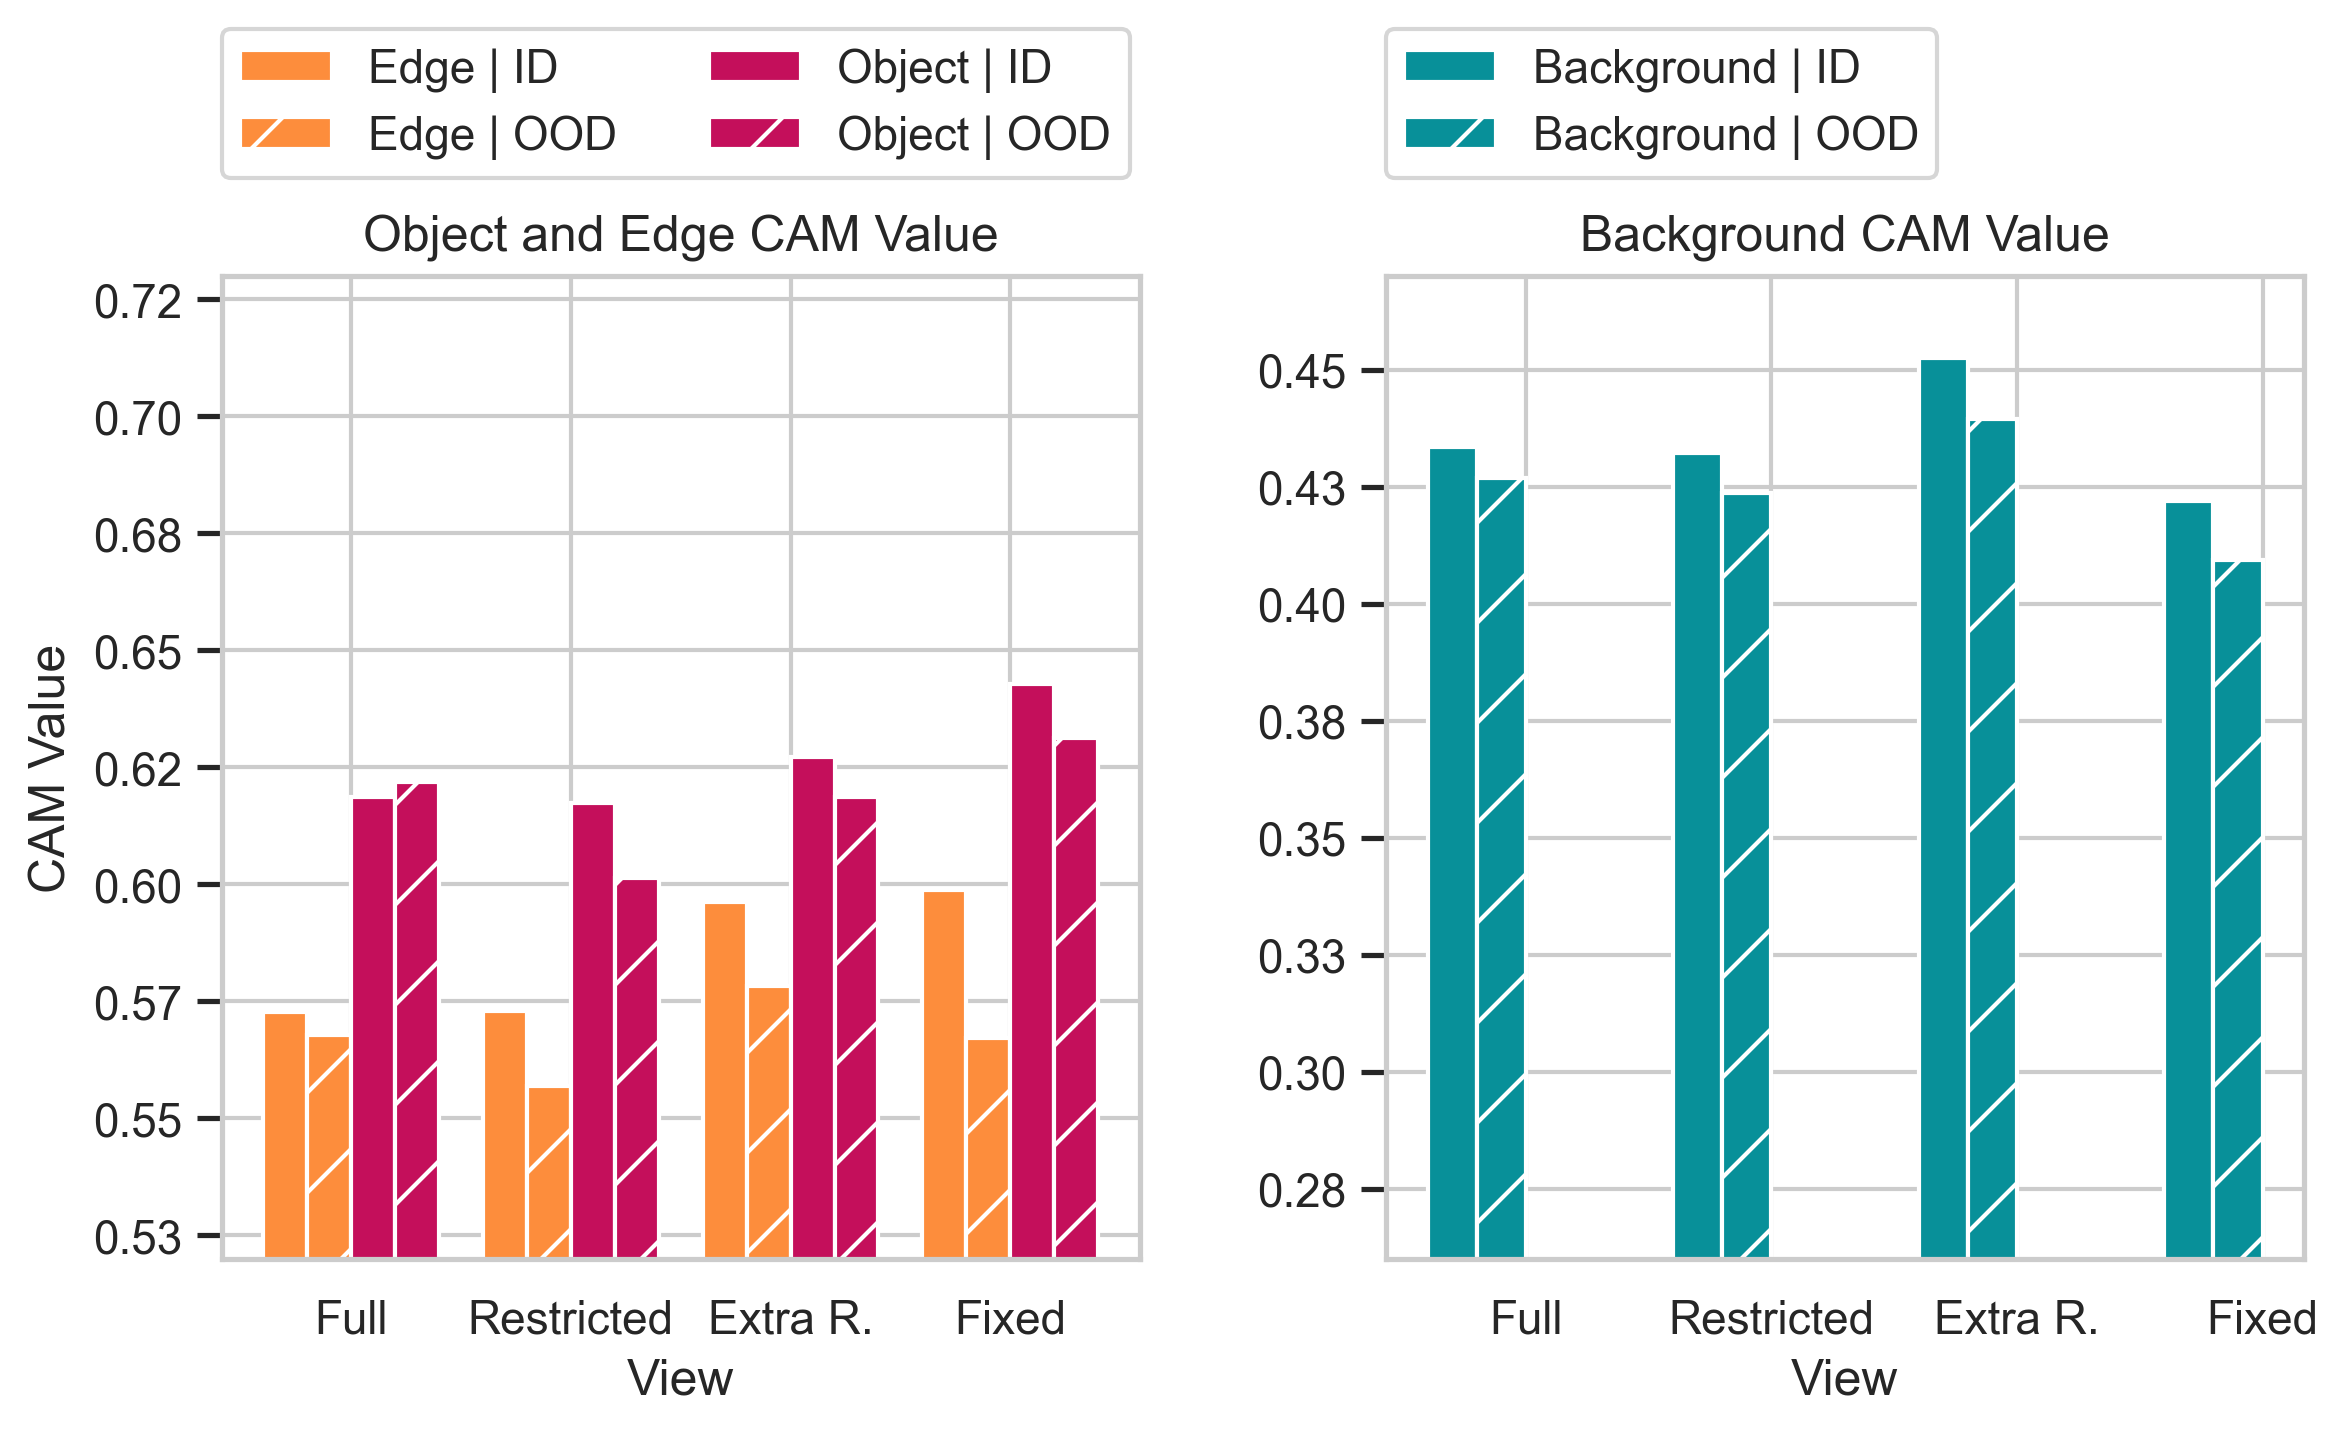

In [67]:
# Generate unique colors for CAM Types and hatches for Data
cam_types = df_ic_bc['CAM Type'].unique()
data_types = df_ic_bc['Data'].unique()
df_avg = df_ic_bc.groupby(['View', 'CAM Type', 'Data'], as_index=False).mean()
df_avg_ec = df_ec.groupby(['View', 'CAM Type', 'Data'], as_index=False).mean()

color_map = palette
hatch_map = {data: hatch for data, hatch in zip(data_types, ['', '/'])}

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))
fig.subplots_adjust(wspace=0.2)

x = np.arange(len(df_avg['View'].unique()))  # Positions for the View categories
bar_width = 0.2  # Width of each bar group
offset = 0  # Initialize offset for grouped bars

views = ['Full', 'Restricted', 'Extra R.', 'Fixed']

# Group bars by 'View'
for i, view in enumerate(views):
    view_data = df_avg[df_avg['View'] == view]
    bars = []
    offset = -1.5 * bar_width
    for j, (_, row) in enumerate(view_data.iterrows()):
        # Get the color and hatch for this bar
        color = color_map[row['CAM Type']]
        hatch = hatch_map[row['Data']]
        # Plot the bar
        bar = ax1.bar(
            x[i] + offset,  # Position of the bar
            row['Value'],  # Height (Value)
            bar_width,  # Width
            color=color,  # Color based on CAM Type
            label=f"{row['CAM Type']} | {row['Data']}" if i == 0 else "",  # Add legend only once
            hatch=hatch  # Hatch pattern based on Data
        )
        bars.append(bar)
        offset += bar_width  # Increment offset for next set of bars

for i, view in enumerate(views):
    view_data = df_avg_ec[df_avg_ec['View'] == view]
    bars = []
    offset = -1.5 * bar_width
    for j, (_, row) in enumerate(view_data.iterrows()):
        # Get the color and hatch for this bar
        color = color_map[row['CAM Type']]
        hatch = hatch_map[row['Data']]
        # Plot the bar
        bar = ax2.bar(
            x[i] + offset,  # Position of the bar
            row['Value'],  # Height (Value)
            bar_width,  # Width
            color=color,  # Color based on CAM Type
            label=f"{row['CAM Type']} | {row['Data']}" if i == 0 else "",  # Add legend only once
            hatch=hatch  # Hatch pattern based on Data
        )
        bars.append(bar)
        offset += bar_width  # Increment offset for next set of bars

# Customize the plot
ax1.set_xlabel('View')
ax1.set_ylabel('CAM Value')
ax1.set_title('Object and Edge CAM Value')
ax1.set_xticks(x)
ax1.set_xticklabels(views)
ax1.set_ylim([0.52, 0.73])

ax2.set_xlabel('View')
ax2.set_ylabel('')
ax2.set_title('Background CAM Value')
ax2.set_xticks(x)
ax2.set_xticklabels(views)
ax2.set_ylim([0.26, 0.47])

ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.legend(ncols=2, loc=(0,1.1))
ax2.legend(loc=(0,1.1))

plt.tight_layout()
plt.savefig('border_cam_plot_cue_conflict_texture_bar.png')

GradCAM++ Image Corruption

In [12]:
data_path = f'../plots/grand_cam_distorted_plot_data.pkl'
with open(data_path, 'rb') as f:
    plot_data = pickle.load(f)
df_matched = plot_data['df_matched']
df_ood = plot_data['df_ood']

df_matched_ec = df_matched[df_matched['CAM Type'] == 'ec']
df_matched_ec['Data'] = 'ID'
df_matched_ic_bc = df_matched[df_matched['CAM Type'] != 'ec']
df_matched_ic_bc['Data'] = 'ID'
df_ood_ec = df_ood[df_ood['CAM Type'] == 'ec']
df_ood_ec['Data'] = 'OOD'
df_ood_ic_bc = df_ood[df_ood['CAM Type'] != 'ec']
df_ood_ic_bc['Data'] = 'OOD'
df_ec = pd.concat([df_matched_ec, df_ood_ec])
df_ic_bc = pd.concat([df_matched_ic_bc, df_ood_ic_bc])

df_ic = df_ic_bc[df_ic_bc['CAM Type'] == 'ic']
df_bc = df_ic_bc[df_ic_bc['CAM Type'] == 'bc']

cam_type_mapping = {'ic': 'Object', 'bc': 'Edge', 'ec': 'Background'}
view_mapping = {'f': 'Full', 'r': 'Restricted', 'er': 'Extra R.', 'fx': 'Fixed'}
df_ec['CAM Type'] = df_ec['CAM Type'].map(cam_type_mapping)
df_ec['View'] = df_ec['View'].map(view_mapping)
df_ic_bc['CAM Type'] = df_ic_bc['CAM Type'].map(cam_type_mapping)
df_ic_bc['View'] = df_ic_bc['View'].map(view_mapping)
df_ic['CAM Type'] = df_ic['CAM Type'].map(cam_type_mapping)
df_ic['View'] = df_ic['View'].map(view_mapping)
df_bc['CAM Type'] = df_bc['CAM Type'].map(cam_type_mapping)
df_bc['View'] = df_bc['View'].map(view_mapping)

/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1486021264.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_ec['Data'] = 'ID'
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1486021264.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_ic_bc['Data'] = 'ID'
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_68469/1486021264.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

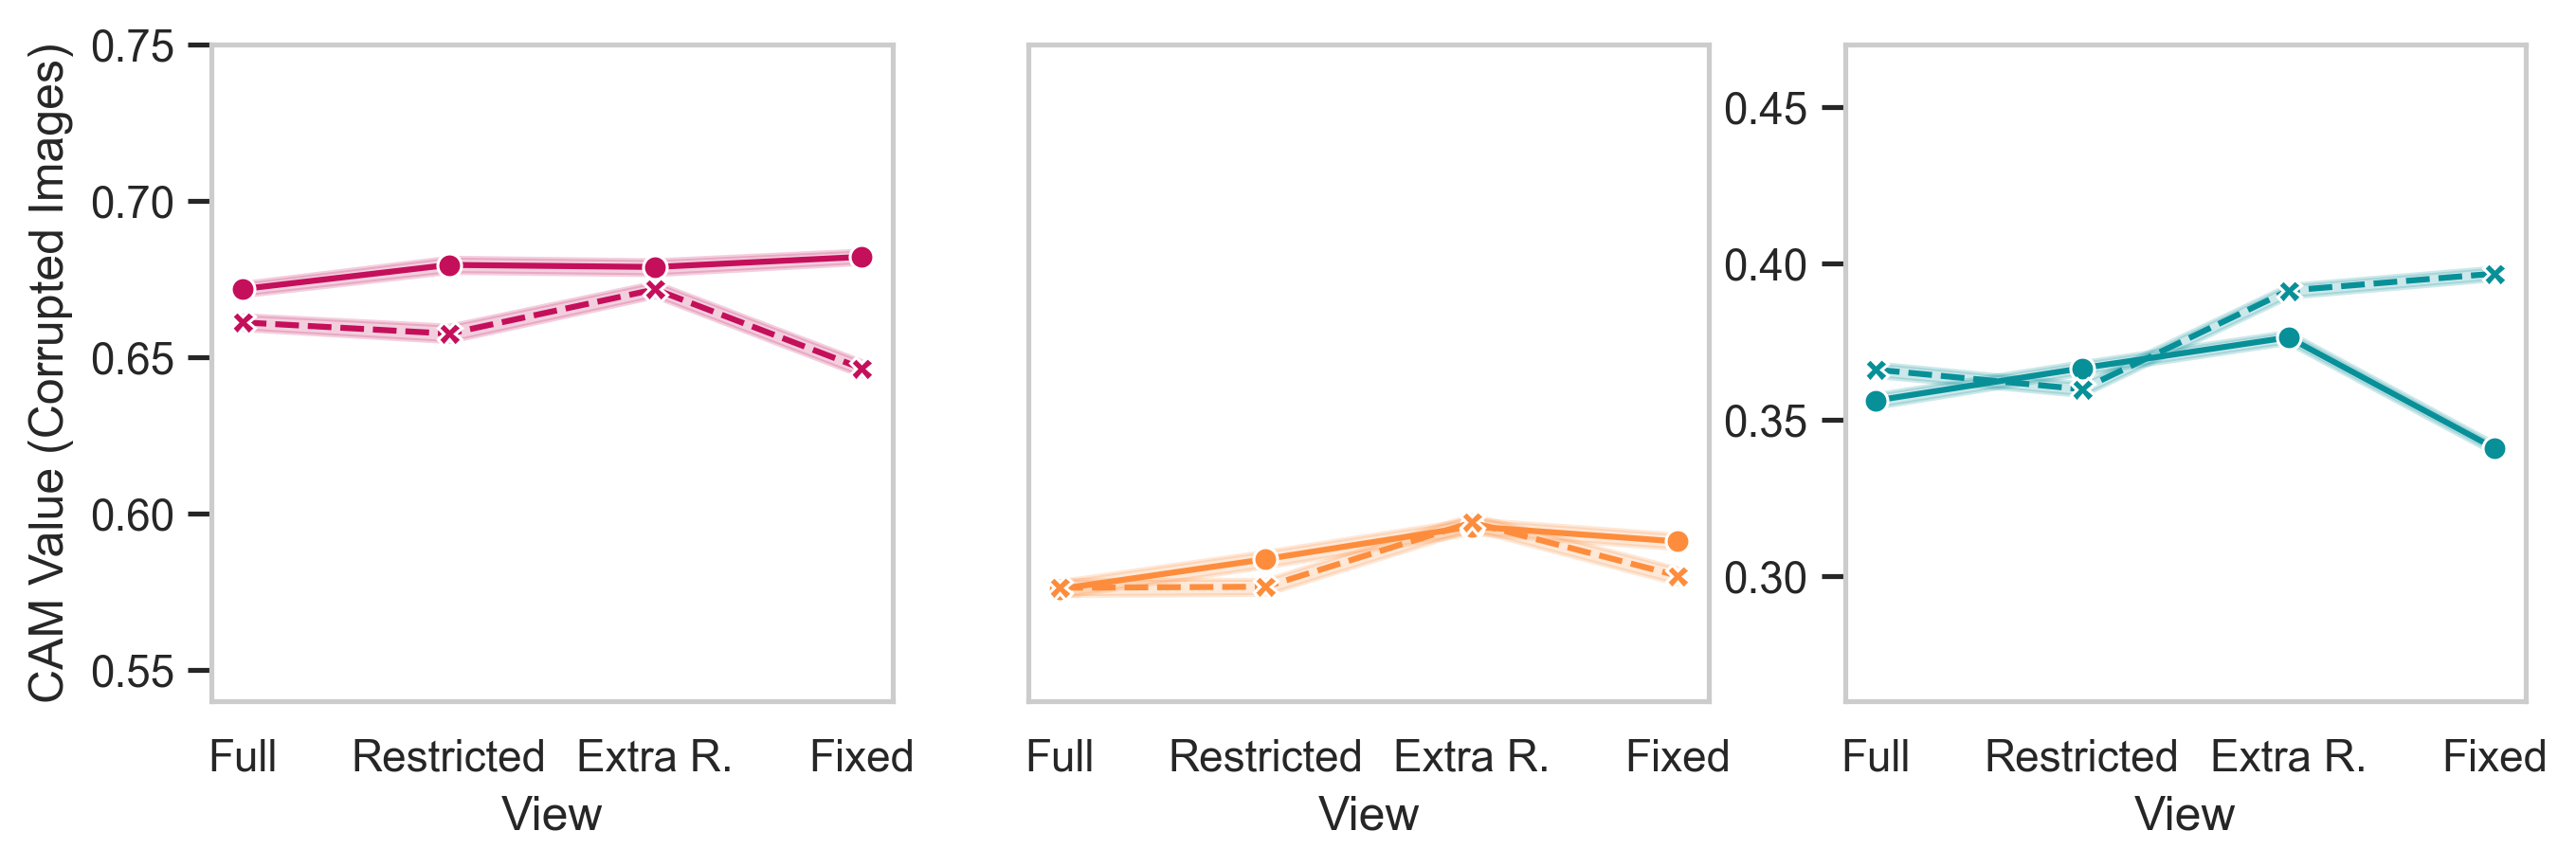

In [13]:
palette = {
    'Object': '#C40F5B',
    'Edge': '#FD8D3C',
    'Background': '#089099',
}

# Create figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(10.5, 3))

sns.lineplot(
    ax=ax1,
    data=df_ic,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,legend=False
)

sns.lineplot(
    ax=ax2,
    data=df_bc,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,legend=False
)

lines = sns.lineplot(
    ax=ax3,
    data=df_ec,
    x="View", y="Value", hue="CAM Type", style='Data', palette=palette,
    markers=True, dashes=True,legend=False
)

# Rest of the styling remains the same
ax1.grid(False)
ax2.grid(False)
ax3.grid(False)
ax2.set_ylabel('')
ax3.set_ylabel('')
ax2.set_yticks([])

ax1.set_ylim([0.54, 0.75])
ax2.set_ylim([0.54, 0.75])
ax3.set_ylim([0.26, 0.47])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_ylabel('CAM Value (Corrupted Images)')
# ax1.set_title('Object CAM')
# ax2.set_title('Edge CAM')
# ax3.set_title('Background CAM')
# ax1.set_xlabel('')
# ax2.set_xlabel('')
# ax3.set_xlabel('')
# ax1.set_xticks([])
# ax2.set_xticks([])
# ax3.set_xticks([])

plt.savefig('grand_cam_distorted.png', bbox_inches='tight')

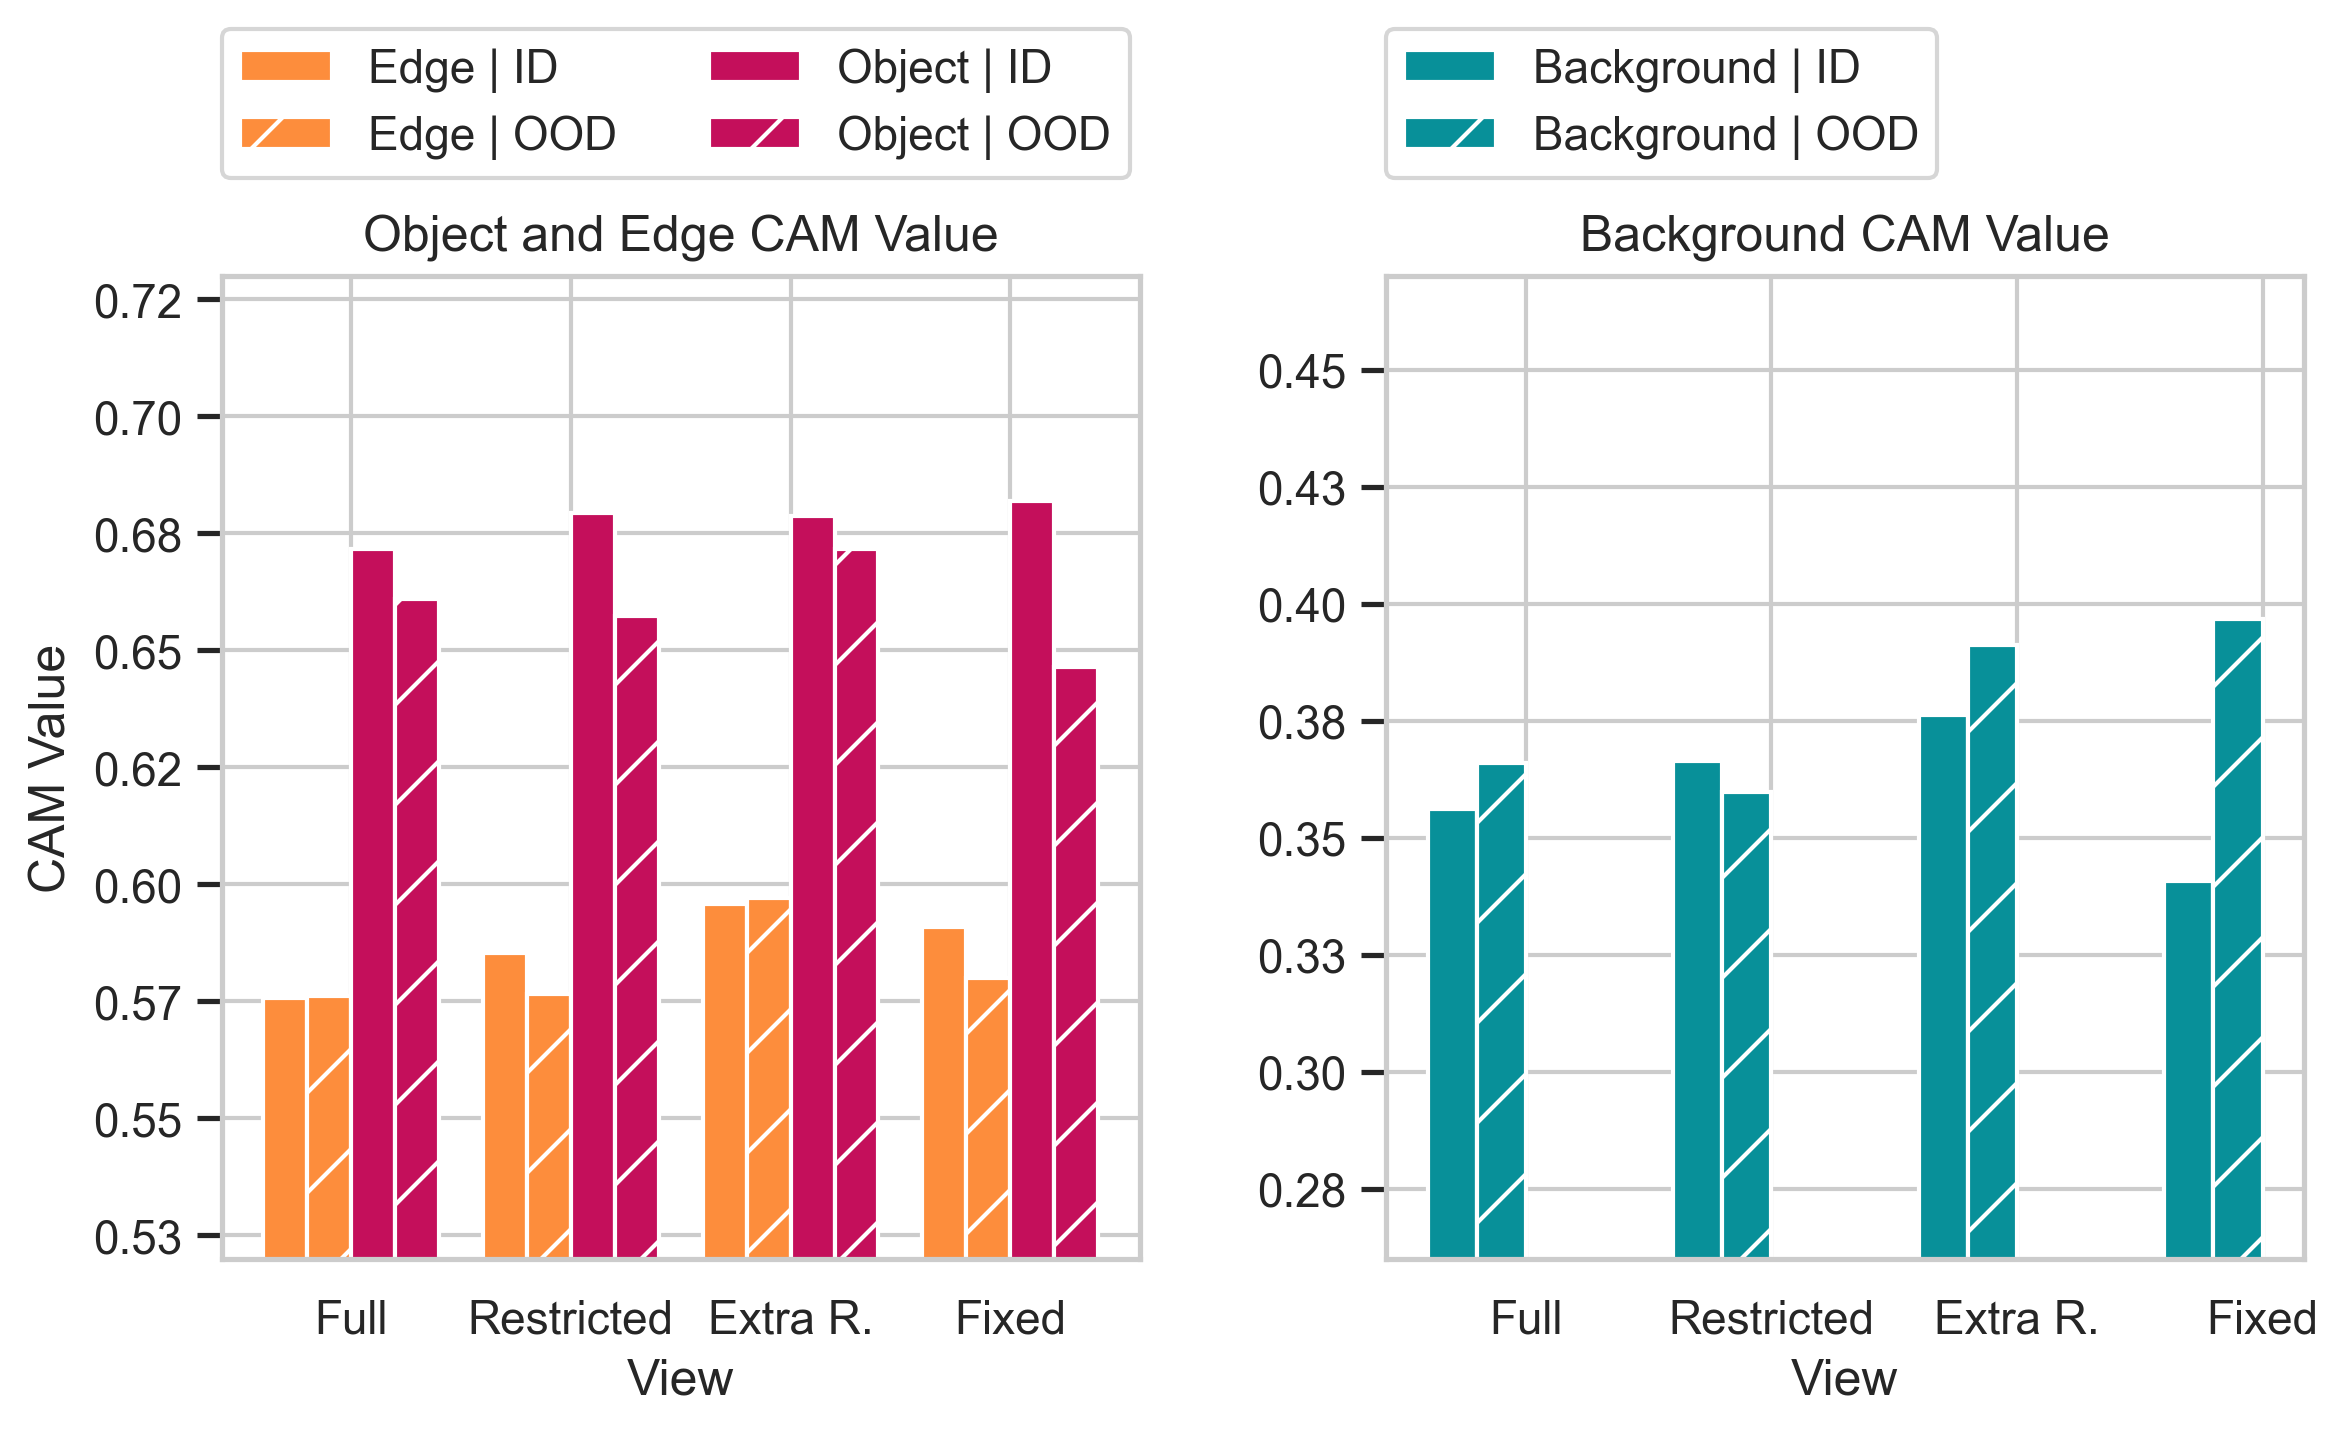

In [70]:
# Generate unique colors for CAM Types and hatches for Data
cam_types = df_ic_bc['CAM Type'].unique()
data_types = df_ic_bc['Data'].unique()
df_avg = df_ic_bc.groupby(['View', 'CAM Type', 'Data'], as_index=False).mean()
df_avg_ec = df_ec.groupby(['View', 'CAM Type', 'Data'], as_index=False).mean()

color_map = palette
hatch_map = {data: hatch for data, hatch in zip(data_types, ['', '/'])}

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))
fig.subplots_adjust(wspace=0.2)

x = np.arange(len(df_avg['View'].unique()))  # Positions for the View categories
bar_width = 0.2  # Width of each bar group
offset = 0  # Initialize offset for grouped bars

views = ['Full', 'Restricted', 'Extra R.', 'Fixed']

# Group bars by 'View'
for i, view in enumerate(views):
    view_data = df_avg[df_avg['View'] == view]
    bars = []
    offset = -1.5 * bar_width
    for j, (_, row) in enumerate(view_data.iterrows()):
        # Get the color and hatch for this bar
        color = color_map[row['CAM Type']]
        hatch = hatch_map[row['Data']]
        # Plot the bar
        bar = ax1.bar(
            x[i] + offset,  # Position of the bar
            row['Value'],  # Height (Value)
            bar_width,  # Width
            color=color,  # Color based on CAM Type
            label=f"{row['CAM Type']} | {row['Data']}" if i == 0 else "",  # Add legend only once
            hatch=hatch  # Hatch pattern based on Data
        )
        bars.append(bar)
        offset += bar_width  # Increment offset for next set of bars

for i, view in enumerate(views):
    view_data = df_avg_ec[df_avg_ec['View'] == view]
    bars = []
    offset = -1.5 * bar_width
    for j, (_, row) in enumerate(view_data.iterrows()):
        # Get the color and hatch for this bar
        color = color_map[row['CAM Type']]
        hatch = hatch_map[row['Data']]
        # Plot the bar
        bar = ax2.bar(
            x[i] + offset,  # Position of the bar
            row['Value'],  # Height (Value)
            bar_width,  # Width
            color=color,  # Color based on CAM Type
            label=f"{row['CAM Type']} | {row['Data']}" if i == 0 else "",  # Add legend only once
            hatch=hatch  # Hatch pattern based on Data
        )
        bars.append(bar)
        offset += bar_width  # Increment offset for next set of bars

# Customize the plot
ax1.set_xlabel('View')
ax1.set_ylabel('CAM Value')
ax1.set_title('Object and Edge CAM Value')
ax1.set_xticks(x)
ax1.set_xticklabels(views)
ax1.set_ylim([0.52, 0.73])

ax2.set_xlabel('View')
ax2.set_ylabel('')
ax2.set_title('Background CAM Value')
ax2.set_xticks(x)
ax2.set_xticklabels(views)
ax2.set_ylim([0.26, 0.47])

ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.legend(ncols=2, loc=(0,1.1))
ax2.legend(loc=(0,1.1))

plt.tight_layout()
plt.savefig('grand_cam_distorted_bar.png')